# Exploratory Data Analysis — TEC SG - GN (Interno)

## Contexto del negocio
Este dataset corresponde a una **cadena de restaurantes de comida japonesa** con **5 sucursales (A–E)** y un corporativo. Contiene datos transaccionales, de costos, nómina y gastos operativos para **enero 2026**.

## Estructura del archivo
| Hoja | Descripción | Filas útiles |
|------|------------|-------------|
| **BD 2026** | Base de datos transaccional (ventas por producto) | 2,678 |
| **GASTOS 2026** | Gastos operativos por sucursal y categoría | 258 |
| **NÓMINA 2026** | Nómina por sucursal y concepto | 24 |
| **INGRESOS ER BASE 2026** | Ingresos mensuales por producto (solo enero con datos) | 2,674 |
| **Glosario ER** | Catálogo de líneas de negocio, categorías y sucursales | — |

## Pipeline del análisis
1. **Carga y limpieza** — Lectura de hojas clave, filtrado de filas vacías, tipado correcto
2. **Análisis de ingresos** — Revenue por sucursal, categoría y producto
3. **Análisis de costos y márgenes** — Estructura de costos, utilidad bruta, productos con margen negativo
4. **Análisis de gastos operativos** — Distribución por categoría y sucursal
5. **Análisis de nómina** — Costo laboral por sucursal
6. **Estado de resultados simplificado** — Visión integrada de rentabilidad

---
## 1. Carga de datos y limpieza

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

FILE = 'TEC SG - GN (Interno).xlsx'

# --- BD 2026: Base transaccional ---
bd = pd.read_excel(FILE, sheet_name='BD 2026')

# --- GASTOS 2026: Gastos operativos ---
gastos_raw = pd.read_excel(FILE, sheet_name='GASTOS 2026')

# --- NÓMINA 2026 ---
nomina_raw = pd.read_excel(FILE, sheet_name='NÓMINA 2026')

# --- Glosario ---
glosario = pd.read_excel(FILE, sheet_name='Glosario ER')

print(f"BD 2026:     {bd.shape}")
print(f"GASTOS 2026: {gastos_raw.shape}")
print(f"NÓMINA 2026: {nomina_raw.shape}")
print(f"Glosario:    {glosario.shape}")

### 1.1 Limpieza de BD 2026

**Pipeline de filtración:**
- Se eliminan columnas completamente vacías (`COL ESPECIAL 4–6`, `FECHA VENTA`)
- Se renombra `COL ESPECIAL 1` → `CATEGORÍA MENÚ` (es la categoría del menú: MAKIS, NIGIRI, BEBIDAS, etc.)
- Se conservan las 50 columnas de costo individual para análisis de estructura de costos
- Se crea `PRECIO_UNITARIO` = SUBTOTAL / CANTIDAD (cuando CANTIDAD > 0)
- Se crea `COSTO_UNITARIO` = COSTO TOTAL SIN IVA / CANTIDAD (cuando CANTIDAD > 0)

In [ ]:
# Eliminar columnas completamente vacías o irrelevantes
drop_cols = ['FECHA VENTA', 'COL ESPECIAL 4', 'COL ESPECIAL 5', 'COL ESPECIAL 6',
             'COL ESPECIAL 2', 'COL ESPECIAL 3']
bd = bd.drop(columns=[c for c in drop_cols if c in bd.columns])

# Renombrar columnas para claridad
bd = bd.rename(columns={
    'COL ESPECIAL 1': 'CATEGORÍA MENÚ',
    'LÍNEA DE NEGOCIO': 'SUCURSAL',
})

# Variables derivadas
bd['PRECIO_UNITARIO'] = np.where(bd['CANTIDAD'] > 0, bd['SUBTOTAL'] / bd['CANTIDAD'], 0)
bd['COSTO_UNITARIO'] = np.where(bd['CANTIDAD'] > 0, bd['COSTO TOTAL SIN IVA'] / bd['CANTIDAD'], 0)

print("Columnas finales BD:", bd.shape[1])
print("\nTipos de datos clave:")
print(bd[['SUCURSAL', 'SUBCATEGORÍA 1', 'CANTIDAD', 'SUBTOTAL', 'TOTAL',
           'COSTO TOTAL SIN IVA', 'UTILIDAD BRUTA', 'MARGEN BRUTO']].dtypes)
print(f"\nRegistros: {len(bd)}")
print(f"Productos únicos (SUBCATEGORÍA 2): {bd['SUBCATEGORÍA 2'].nunique()}")
print(f"Sucursales: {sorted(bd['SUCURSAL'].unique())}")
bd.head(3)

Columnas finales BD: 64

Tipos de datos clave:
SUCURSAL                object
SUBCATEGORÍA 1          object
CANTIDAD               float64
SUBTOTAL               float64
TOTAL                  float64
COSTO TOTAL SIN IVA    float64
UTILIDAD BRUTA         float64
MARGEN BRUTO           float64
dtype: object

Registros: 2678
Productos únicos (SUBCATEGORÍA 2): 1764
Sucursales: ['A', 'B', 'C', 'D', 'E']


,MES,SUCURSAL,SUBCATEGORÍA 1,SUBCATEGORÍA 2,CANTIDAD,SUBTOTAL,TOTAL,COSTO 1,COSTO 2,COSTO 3,...,COSTO 48,COSTO 49,COSTO 50,COSTO TOTAL SIN IVA,COSTO TOTAL DEL SERVICIO,UTILIDAD BRUTA,MARGEN BRUTO,CATEGORÍA MENÚ,PRECIO_UNITARIO,COSTO_UNITARIO
0,ENERO 2026,A,Alimentos,YAKIMESHI MIXTO,959.0,152135.84,176477.5744,36783.88350,NaN,NaN,...,NaN,NaN,NaN,36783.88350,42669.30486,115351.95650,0.758217,CALIENTE,158.640083,38.356500
1,ENERO 2026,A,Alimentos,LOBSTER ROLL,458.0,107989.65,125267.9940,50819.87831,NaN,NaN,...,NaN,NaN,NaN,50819.87831,58951.05884,57169.77169,0.529400,MAKIS,235.785262,110.960433
2,ENERO 2026,A,Alimentos,CRISPY TUNA,512.0,103055.61,119544.5076,36479.92832,NaN,NaN,...,NaN,NaN,NaN,36479.92832,42316.71685,66575.68168,0.646017,MAKIS,201.280488,71.249860


### 1.2 Diagnóstico: registros con margen bruto = 0

Antes de continuar, es importante entender por qué hay un gran conteo de `MARGEN BRUTO == 0`. El diagnóstico revela que son **productos del catálogo sin ventas en enero** (SUBTOTAL=0, CANTIDAD=0). No aportan información al análisis de rentabilidad y deben filtrarse.

In [ ]:
# --- Diagnóstico de MARGEN BRUTO == 0 ---
total = len(bd)
zero_margin = (bd['MARGEN BRUTO'] == 0).sum()
zero_subtotal = (bd['SUBTOTAL'] == 0).sum()
zero_cantidad = (bd['CANTIDAD'] == 0).sum()

print(f"Total registros:        {total}")
print(f"MARGEN BRUTO == 0:      {zero_margin} ({zero_margin/total:.1%})")
print(f"SUBTOTAL == 0:          {zero_subtotal} ({zero_subtotal/total:.1%})")
print(f"CANTIDAD == 0:          {zero_cantidad} ({zero_cantidad/total:.1%})")

# ¿Qué pasa cuando margen=0?
m0 = bd[bd['MARGEN BRUTO'] == 0]
both_zero = ((m0['SUBTOTAL'] == 0) & (m0['COSTO TOTAL SIN IVA'] == 0)).sum()
sub_zero_cost_pos = ((m0['SUBTOTAL'] == 0) & (m0['COSTO TOTAL SIN IVA'] > 0)).sum()

print(f"\nDe los {zero_margin} registros con margen=0:")
print(f"  - {both_zero} tienen SUBTOTAL=0 Y COSTO=0 (productos sin venta, 'placeholders')")
print(f"  - {sub_zero_cost_pos} tienen SUBTOTAL=0 pero COSTO>0 (cortesías/promos con costo)")
print(f"  - {zero_margin - both_zero - sub_zero_cost_pos} otros")

# Distribución por sucursal
print(f"\nRegistros con margen=0 por sucursal:")
print(bd.groupby('SUCURSAL')['MARGEN BRUTO'].apply(lambda x: f"{(x==0).sum()} de {len(x)} ({(x==0).mean():.0%})").to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del filtro
axes[0].hist(bd['MARGEN BRUTO'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'ANTES del filtro (n={total})\nGran pico en 0 por productos sin venta')
axes[0].set_xlabel('Margen Bruto')
axes[0].annotate(f'{zero_margin} registros\n(44.7%)', xy=(0, zero_margin*0.8),
                  fontsize=11, color='red', fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='red'), xytext=(0.3, zero_margin*0.8))

# Después del filtro
bd_activo = bd[bd['SUBTOTAL'] > 0]
axes[1].hist(bd_activo['MARGEN BRUTO'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'DESPUÉS del filtro (n={len(bd_activo)})\nSolo productos con ventas reales')
axes[1].set_xlabel('Margen Bruto')
axes[1].axvline(bd_activo['MARGEN BRUTO'].mean(), color='red', linestyle='--',
                 label=f"Media: {bd_activo['MARGEN BRUTO'].mean():.1%}")
axes[1].axvline(bd_activo['MARGEN BRUTO'].median(), color='orange', linestyle='--',
                 label=f"Mediana: {bd_activo['MARGEN BRUTO'].median():.1%}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- FILTRO: Conservar solo productos con ventas reales ---
# Se mantiene bd original para referencia del catálogo completo
bd_all = bd.copy()  # catálogo completo (2,678)
bd = bd[bd['SUBTOTAL'] > 0].copy()  # solo productos vendidos

print(f"Registros originales:       {len(bd_all)}")
print(f"Registros con venta real:   {len(bd)} ({len(bd)/len(bd_all):.1%})")
print(f"Registros filtrados (sin venta): {len(bd_all) - len(bd)}")
print(f"\nProductos únicos con venta: {bd['SUBCATEGORÍA 2'].nunique()} de {bd_all['SUBCATEGORÍA 2'].nunique()} en catálogo")
print(f"\nNuevo margen bruto promedio: {bd['MARGEN BRUTO'].mean():.1%} (antes: {bd_all['MARGEN BRUTO'].mean():.1%})")
print(f"Nueva mediana:               {bd['MARGEN BRUTO'].median():.1%} (antes: {bd_all['MARGEN BRUTO'].median():.1%})")

### 1.3 Limpieza de GASTOS y NÓMINA

**Pipeline:**
- **GASTOS**: Se filtran filas con `FECHA GASTO` no nula (258 de 999 filas útiles). Se eliminan filas sin categoría.
- **NÓMINA**: Se filtran filas con `FECHA NÓMINA` no nula (24 filas útiles). Se renombra `Unnamed: 3` → `CONCEPTO_NÓMINA`.

In [ ]:
# --- GASTOS: filtrar filas válidas ---
gastos = gastos_raw[gastos_raw['FECHA GASTO'].notna()].copy()
gastos = gastos[gastos['CATEGORÍA GASTO'].notna()]
gastos = gastos.drop(columns=['TOTAL'], errors='ignore')  # Columna completamente vacía
print(f"GASTOS después de limpieza: {gastos.shape}")
print(f"  Sucursales: {sorted(gastos['SUCURSAL'].dropna().unique())}")
print(f"  Categorías: {sorted(gastos['CATEGORÍA GASTO'].unique())}")

# --- NÓMINA: filtrar filas válidas ---
nomina = nomina_raw[nomina_raw['FECHA NÓMINA'].notna()].copy()
nomina = nomina.rename(columns={'Unnamed: 3': 'CONCEPTO_NÓMINA'})
nomina = nomina.drop(columns=['Unnamed: 4', 'CONCEPTO', 'TOTAL'], errors='ignore')
print(f"\nNÓMINA después de limpieza: {nomina.shape}")
print(f"  Sucursales: {sorted(nomina['SUCURSAL'].unique())}")
print(f"  Conceptos: {sorted(nomina['CONCEPTO_NÓMINA'].unique())}")
nomina.head()

GASTOS después de limpieza: (192, 6)
  Sucursales: ['A', 'B', 'C', 'Corporativo', 'D', 'E']
  Categorías: ['Gastos Administrativos', 'Gastos Comerciales', 'Gastos Financieros', 'Gastos Operativos', 'Viáticos']

NÓMINA después de limpieza: (24, 5)
  Sucursales: ['A', 'B', 'C', 'Corporativo', 'D', 'E']
  Conceptos: ['Finiquitos', 'Imss', 'Nomina Corporativa', 'Nomina Operativa']


,MES NÓMINA,FECHA NÓMINA,SUCURSAL,CONCEPTO_NÓMINA,SUBTOTAL
0,ENERO 2026,2026-01-31,A,Nomina Operativa,362738.0517
1,ENERO 2026,2026-01-31,A,Finiquitos,0.0000
2,ENERO 2026,2026-01-31,A,Imss,122154.0500
3,ENERO 2026,2026-01-31,A,Nomina Corporativa,161467.8883
5,ENERO 2026,2026-01-31,E,Nomina Operativa,131434.1568


---
## 2. Análisis de ingresos por sucursal y categoría

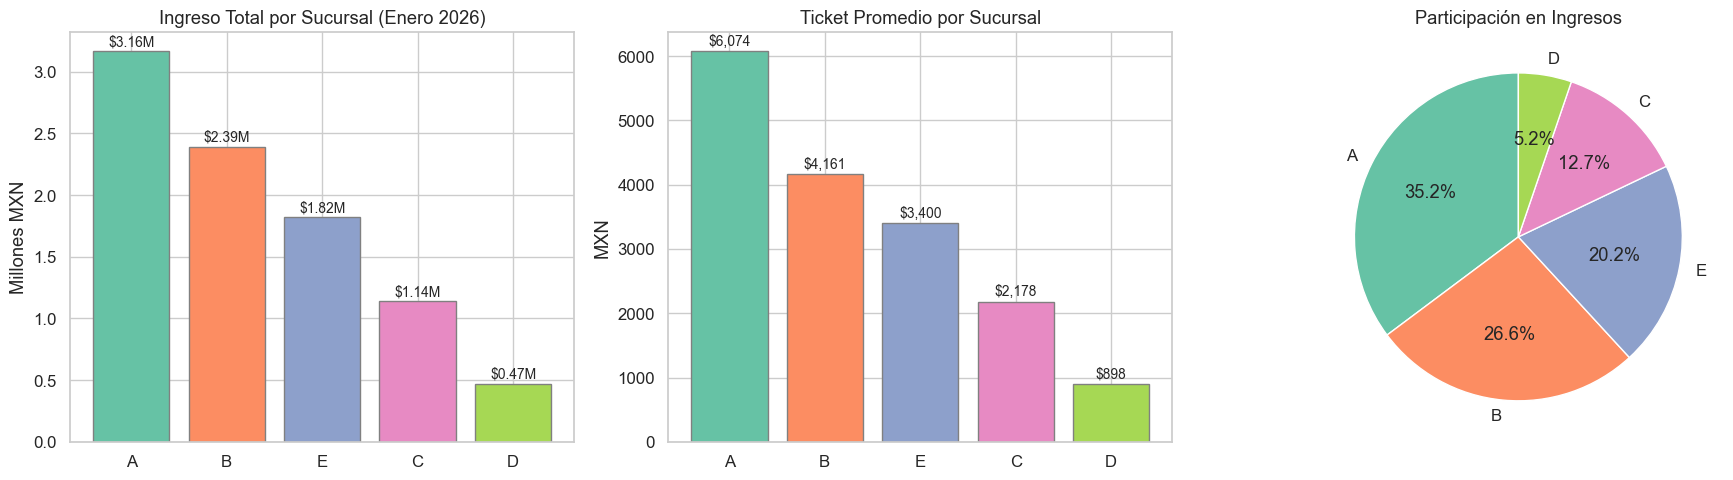

          Transacciones  Ingreso_Total  Ticket_Promedio  Cantidad_Total
SUCURSAL                                                               
A                   521  $3,164,778.72        $6,074.43      $24,983.70
B                   575  $2,392,550.65        $4,160.96      $29,406.43
E                   535  $1,819,229.95        $3,400.43      $16,010.30
C                   523  $1,139,072.01        $2,177.96      $10,498.00
D                   524    $470,759.29          $898.40       $5,072.00


In [ ]:
# --- 2.1 Revenue por sucursal ---
rev_suc = bd.groupby('SUCURSAL').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso_Total=('SUBTOTAL', 'sum'),
    Ticket_Promedio=('SUBTOTAL', 'mean'),
    Cantidad_Total=('CANTIDAD', 'sum'),
).sort_values('Ingreso_Total', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barplot de ingresos
colors = sns.color_palette('Set2', n_colors=5)
bars = axes[0].bar(rev_suc.index, rev_suc['Ingreso_Total'] / 1e6, color=colors, edgecolor='gray')
axes[0].set_title('Ingreso Total por Sucursal (Enero 2026)')
axes[0].set_ylabel('Millones MXN')
for bar, val in zip(bars, rev_suc['Ingreso_Total']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=10)

# Ticket promedio
bars2 = axes[1].bar(rev_suc.index, rev_suc['Ticket_Promedio'], color=colors, edgecolor='gray')
axes[1].set_title('Ticket Promedio por Sucursal')
axes[1].set_ylabel('MXN')
for bar, val in zip(bars2, rev_suc['Ticket_Promedio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

# Pie de participación
axes[2].pie(rev_suc['Ingreso_Total'], labels=rev_suc.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[2].set_title('Participación en Ingresos')

plt.tight_layout()
plt.show()

print(rev_suc.to_string(float_format='${:,.2f}'.format))

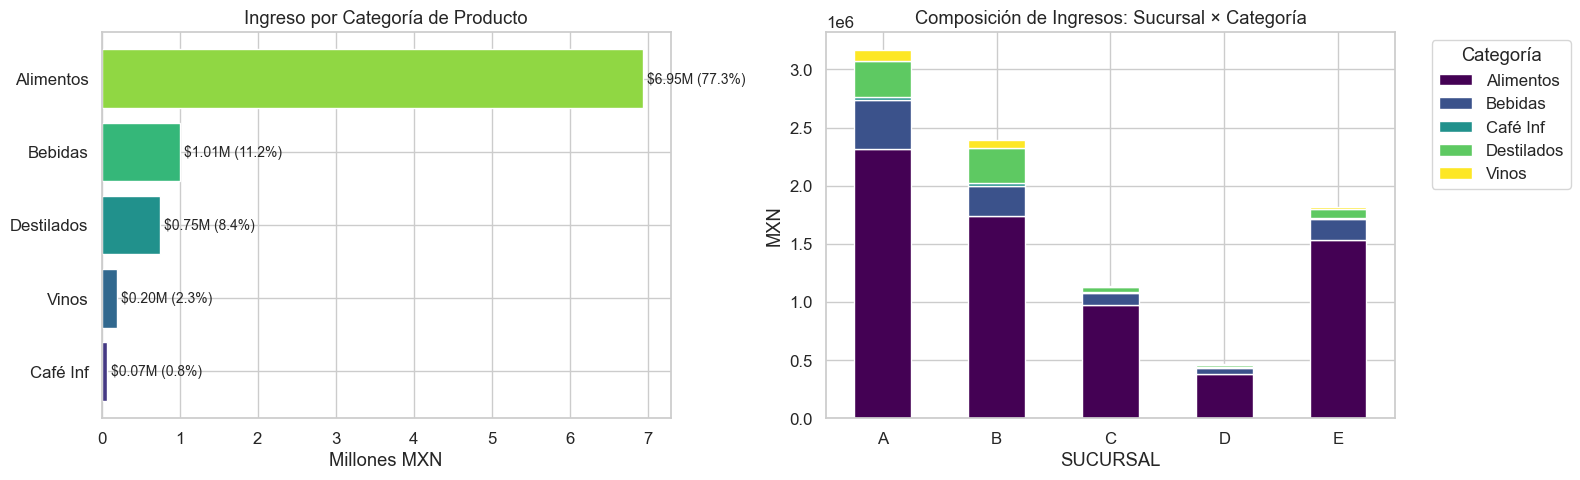

In [ ]:
# --- 2.2 Revenue por categoría de producto (SUBCATEGORÍA 1) ---
rev_cat = bd.groupby('SUBCATEGORÍA 1').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso_Total=('SUBTOTAL', 'sum'),
    Pct_Ingreso=('SUBTOTAL', lambda x: x.sum() / bd['SUBTOTAL'].sum() * 100),
    Cantidad_Total=('CANTIDAD', 'sum'),
).sort_values('Ingreso_Total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot horizontal
rev_cat_sorted = rev_cat.sort_values('Ingreso_Total')
axes[0].barh(rev_cat_sorted.index, rev_cat_sorted['Ingreso_Total'] / 1e6, color=sns.color_palette('viridis', 5))
axes[0].set_xlabel('Millones MXN')
axes[0].set_title('Ingreso por Categoría de Producto')
for i, (val, pct) in enumerate(zip(rev_cat_sorted['Ingreso_Total'], rev_cat_sorted['Pct_Ingreso'])):
    axes[0].text(val/1e6 + 0.05, i, f'${val/1e6:.2f}M ({pct:.1f}%)', va='center', fontsize=10)

# Stacked bar: categoría × sucursal
pivot = bd.pivot_table(values='SUBTOTAL', index='SUCURSAL', columns='SUBCATEGORÍA 1', aggfunc='sum', fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Composición de Ingresos: Sucursal × Categoría')
axes[1].set_ylabel('MXN')
axes[1].legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

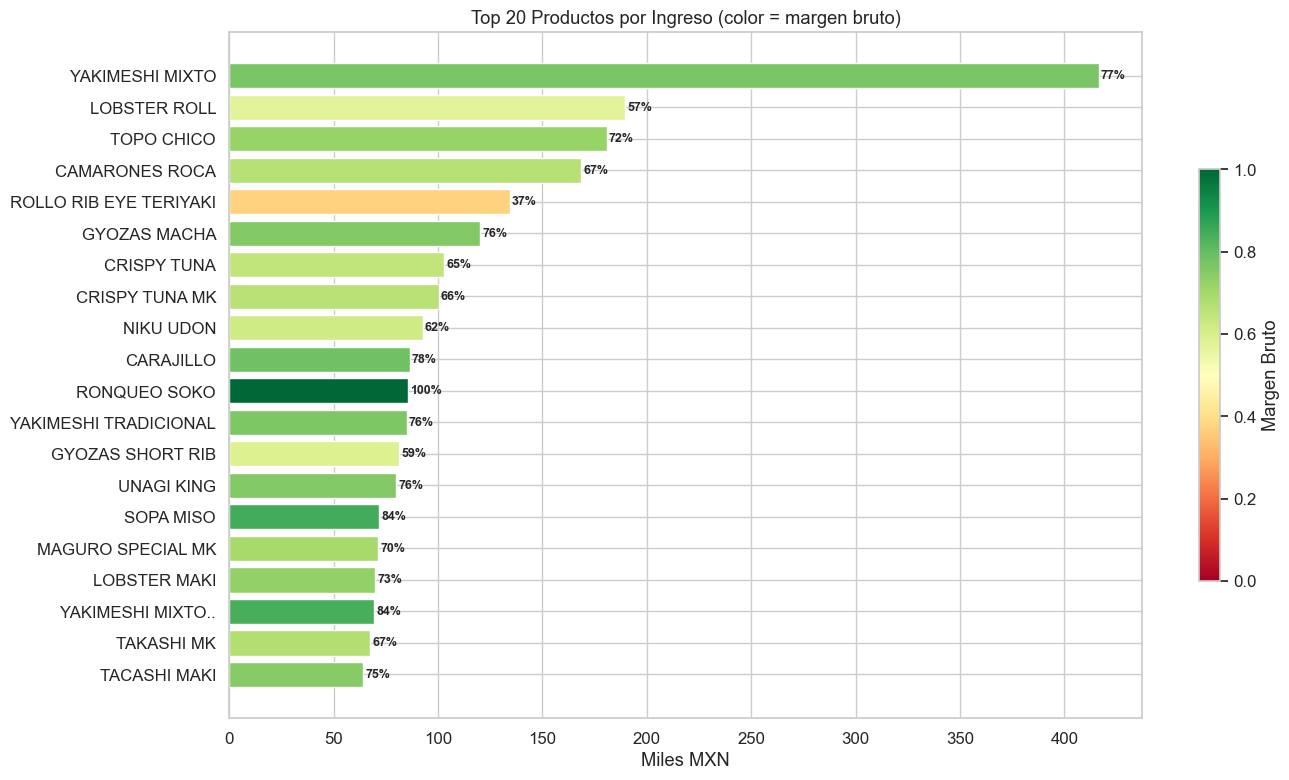

In [ ]:
# --- 2.3 Top 20 productos por ingreso ---
top20 = bd.groupby('SUBCATEGORÍA 2').agg(
    Cantidad=('CANTIDAD', 'sum'),
    Ingreso=('SUBTOTAL', 'sum'),
    Margen_Prom=('MARGEN BRUTO', 'mean'),
).sort_values('Ingreso', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20.index[::-1], top20['Ingreso'][::-1] / 1000,
               color=[plt.cm.RdYlGn(m) for m in top20['Margen_Prom'][::-1]])
ax.set_xlabel('Miles MXN')
ax.set_title('Top 20 Productos por Ingreso (color = margen bruto)')

# Añadir margen como texto
for i, (ing, marg) in enumerate(zip(top20['Ingreso'][::-1], top20['Margen_Prom'][::-1])):
    ax.text(ing/1000 + 1, i, f'{marg:.0%}', va='center', fontsize=9, fontweight='bold')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Margen Bruto')

plt.tight_layout()
plt.show()

---
## 3. Análisis de costos y márgenes

**Justificación:** El margen bruto es la métrica central de rentabilidad a nivel producto. Entender su distribución permite identificar productos que destruyen valor y oportunidades de optimización de precios/costos.

> **Nota:** A partir de aquí, todos los análisis usan `bd` filtrado (solo productos con ventas reales, sin los ~1,196 registros placeholder con SUBTOTAL=0).

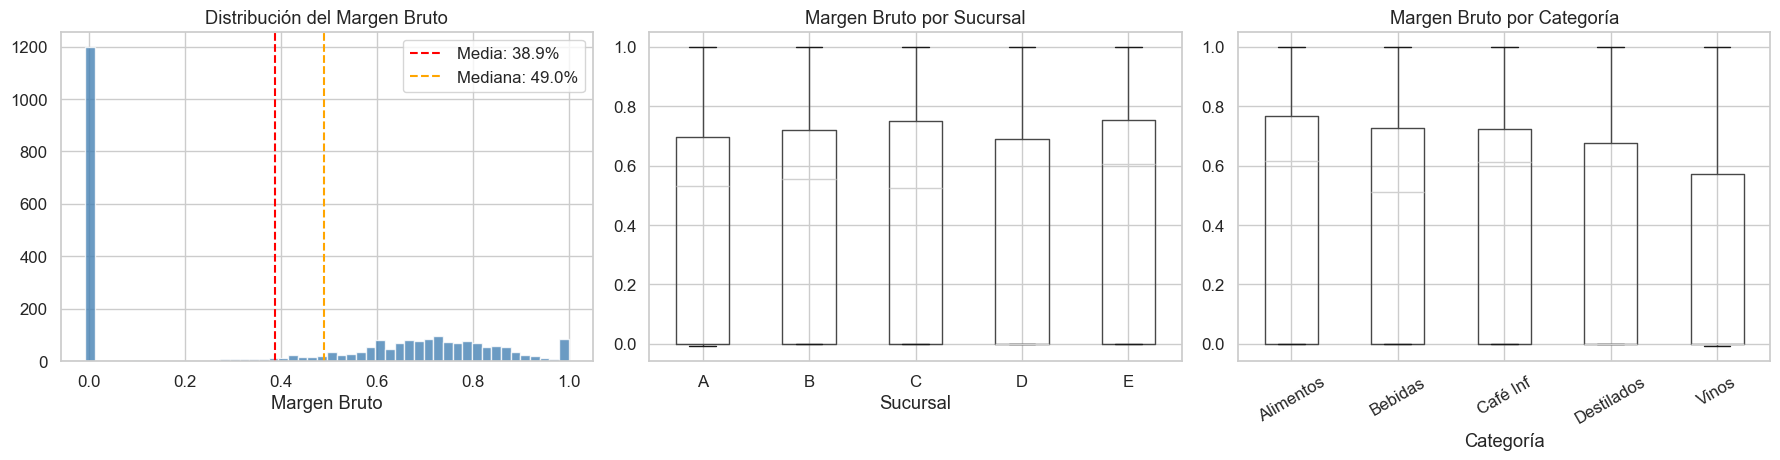

Margen bruto por sucursal:
           mean    50%    std    min     max
SUCURSAL                                    
A        38.96% 52.94% 34.95% -0.79% 100.00%
B        41.05% 55.34% 35.68%  0.00% 100.00%
C        40.94% 52.45% 36.85%  0.00% 100.00%
D        26.77%  0.00% 39.62%  0.00% 100.00%
E        46.39% 60.66% 35.15%  0.00% 100.00%


In [ ]:
# --- 3.1 Distribución del margen bruto ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma general
axes[0].hist(bd['MARGEN BRUTO'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(bd['MARGEN BRUTO'].mean(), color='red', linestyle='--', label=f"Media: {bd['MARGEN BRUTO'].mean():.1%}")
axes[0].axvline(bd['MARGEN BRUTO'].median(), color='orange', linestyle='--', label=f"Mediana: {bd['MARGEN BRUTO'].median():.1%}")
axes[0].set_title('Distribución del Margen Bruto')
axes[0].set_xlabel('Margen Bruto')
axes[0].legend()

# Boxplot por sucursal
bd.boxplot(column='MARGEN BRUTO', by='SUCURSAL', ax=axes[1])
axes[1].set_title('Margen Bruto por Sucursal')
axes[1].set_xlabel('Sucursal')
plt.suptitle('')

# Boxplot por categoría
bd.boxplot(column='MARGEN BRUTO', by='SUBCATEGORÍA 1', ax=axes[2])
axes[2].set_title('Margen Bruto por Categoría')
axes[2].set_xlabel('Categoría')
axes[2].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("Margen bruto por sucursal:")
print(bd.groupby('SUCURSAL')['MARGEN BRUTO'].describe()[['mean', '50%', 'std', 'min', 'max']].to_string(float_format='{:.2%}'.format))

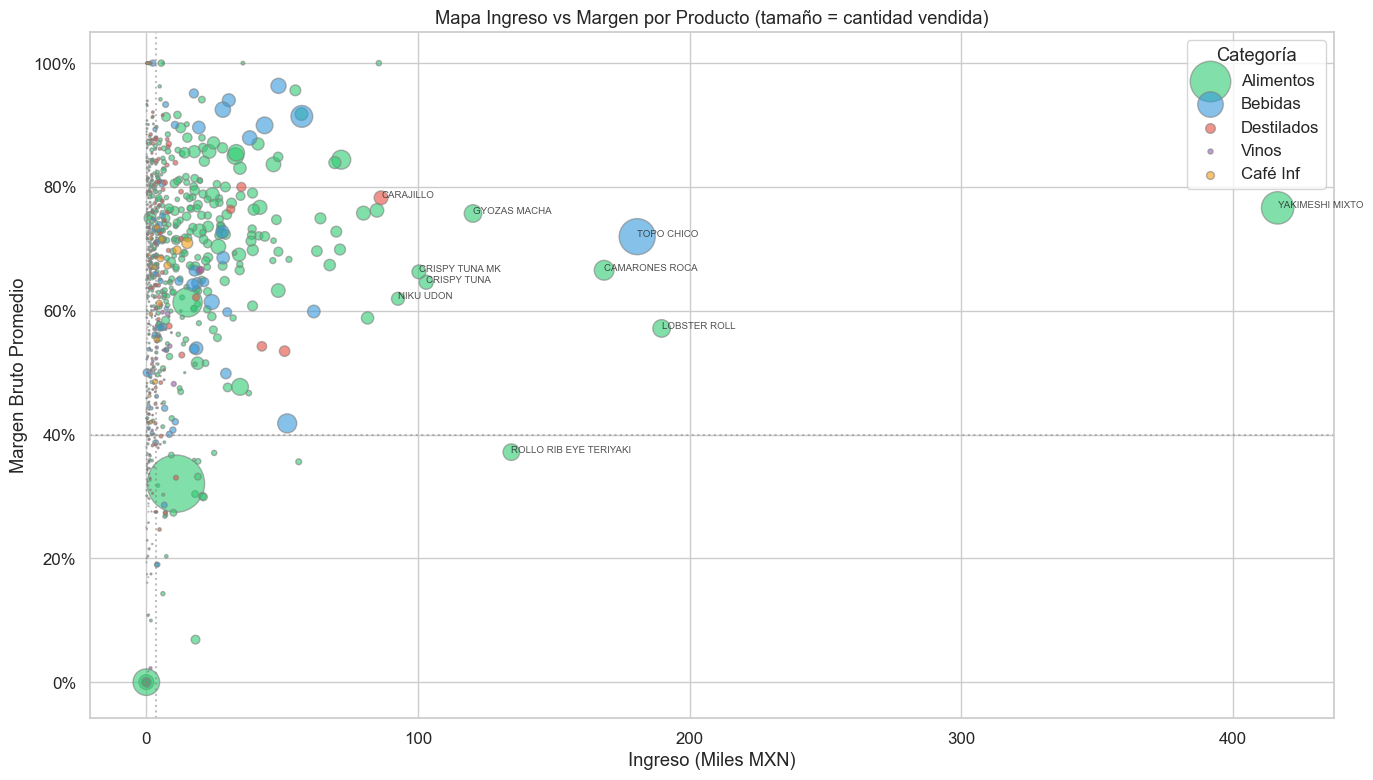

In [ ]:
# --- 3.2 Scatter: Ingreso vs Margen por producto ---
prod_agg = bd.groupby('SUBCATEGORÍA 2').agg(
    Ingreso=('SUBTOTAL', 'sum'),
    Margen=('MARGEN BRUTO', 'mean'),
    Cantidad=('CANTIDAD', 'sum'),
    Categoria=('SUBCATEGORÍA 1', 'first'),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
cat_colors = {'Alimentos': '#2ecc71', 'Bebidas': '#3498db', 'Destilados': '#e74c3c',
              'Vinos': '#9b59b6', 'Café Inf': '#f39c12'}

for cat, color in cat_colors.items():
    mask = prod_agg['Categoria'] == cat
    ax.scatter(prod_agg.loc[mask, 'Ingreso'] / 1000, prod_agg.loc[mask, 'Margen'],
               s=prod_agg.loc[mask, 'Cantidad'] / 5, alpha=0.6, label=cat, color=color, edgecolors='gray')

# Cuadrantes
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5)
ax.axvline(prod_agg['Ingreso'].quantile(0.75) / 1000, color='gray', linestyle=':', alpha=0.5)

# Etiquetar top productos
for _, row in prod_agg.nlargest(10, 'Ingreso').iterrows():
    ax.annotate(row['SUBCATEGORÍA 2'], (row['Ingreso']/1000, row['Margen']),
                fontsize=7, alpha=0.8, ha='left')

ax.set_xlabel('Ingreso (Miles MXN)')
ax.set_ylabel('Margen Bruto Promedio')
ax.set_title('Mapa Ingreso vs Margen por Producto (tamaño = cantidad vendida)')
ax.legend(title='Categoría')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

In [ ]:
# --- 3.3 Productos con margen negativo o cero ---
neg_margin = bd[bd['UTILIDAD BRUTA'] < 0][['SUCURSAL', 'SUBCATEGORÍA 1', 'SUBCATEGORÍA 2',
                                             'CANTIDAD', 'SUBTOTAL', 'COSTO TOTAL SIN IVA',
                                             'UTILIDAD BRUTA', 'MARGEN BRUTO']].sort_values('UTILIDAD BRUTA')

print(f"Productos con utilidad bruta negativa: {len(neg_margin)}")
print(f"Pérdida total por margen negativo: ${neg_margin['UTILIDAD BRUTA'].sum():,.2f} MXN\n")
neg_margin

Productos con utilidad bruta negativa: 8
Pérdida total por margen negativo: $-10,624.98 MXN



,SUCURSAL,SUBCATEGORÍA 1,SUBCATEGORÍA 2,CANTIDAD,SUBTOTAL,COSTO TOTAL SIN IVA,UTILIDAD BRUTA,MARGEN BRUTO
866,B,Alimentos,POSTRE CUMPLEAÑOS,233.0,0.00,7909.468095,-7909.468095,0.000000
2596,E,Alimentos,!!EMPAQUE!!,44.0,0.00,2238.280000,-2238.280000,0.000000
1008,B,Alimentos,KATEN SOKO,1833.0,0.00,153.273627,-153.273627,0.000000
1038,B,Destilados,ST GERMAIN SPRITZ COPIA,2.0,0.00,123.886552,-123.886552,0.000000
874,B,Bebidas,AGUA NAT HETHE 750,3.0,0.00,114.000000,-114.000000,0.000000
1037,B,Destilados,APEROL SPRITZ PROMO.,2.0,0.00,61.160000,-61.160000,0.000000
2066,D,Alimentos,NG KAMPACHI,1.0,0.00,18.694733,-18.694733,0.000000
264,A,Vinos,"KENDALL, CHARDONNAY",1.0,784.48,790.698276,-6.218276,-0.007927


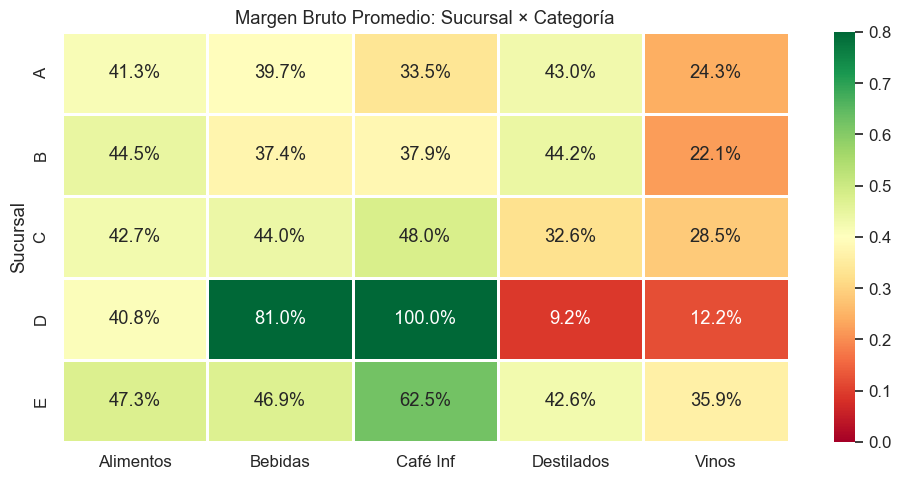

In [ ]:
# --- 3.4 Heatmap: Margen bruto promedio por Sucursal × Categoría ---
margin_pivot = bd.pivot_table(values='MARGEN BRUTO', index='SUCURSAL',
                               columns='SUBCATEGORÍA 1', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(margin_pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0.4,
            linewidths=1, ax=ax, vmin=0, vmax=0.8)
ax.set_title('Margen Bruto Promedio: Sucursal × Categoría')
ax.set_ylabel('Sucursal')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

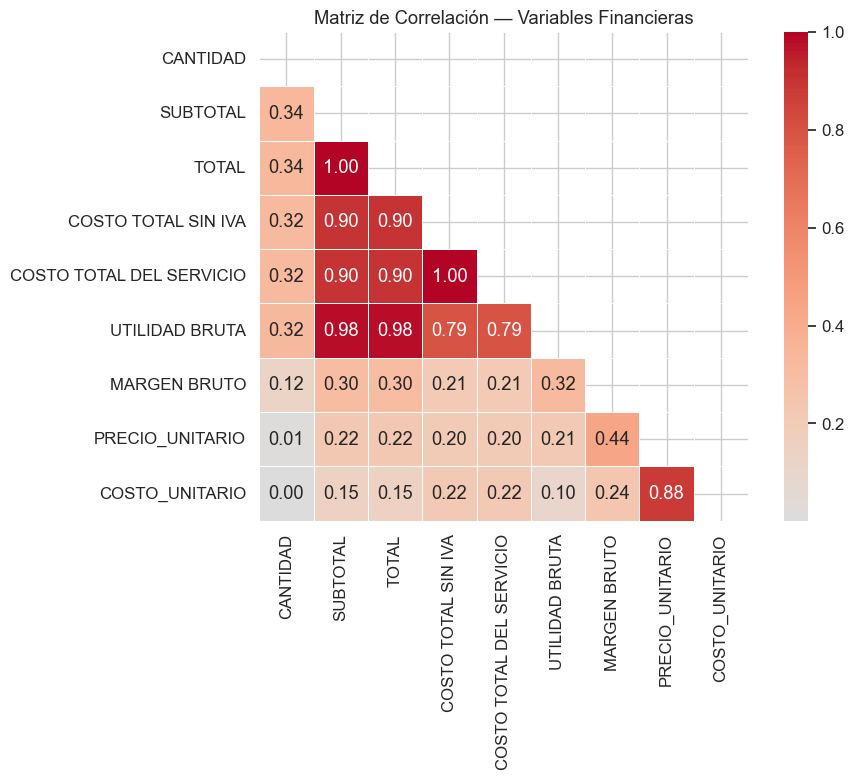

In [ ]:
# --- 3.5 Correlación entre variables financieras clave ---
fin_cols = ['CANTIDAD', 'SUBTOTAL', 'TOTAL', 'COSTO TOTAL SIN IVA',
            'COSTO TOTAL DEL SERVICIO', 'UTILIDAD BRUTA', 'MARGEN BRUTO',
            'PRECIO_UNITARIO', 'COSTO_UNITARIO']

fig, ax = plt.subplots(figsize=(10, 8))
corr = bd[fin_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación — Variables Financieras')
plt.tight_layout()
plt.show()

---
## 4. Análisis de gastos operativos

**Justificación:** Los gastos operativos son el segundo gran componente del estado de resultados después del costo de ventas. Su distribución por categoría y sucursal revela dónde se concentra la estructura de costos fijos y variables del negocio.

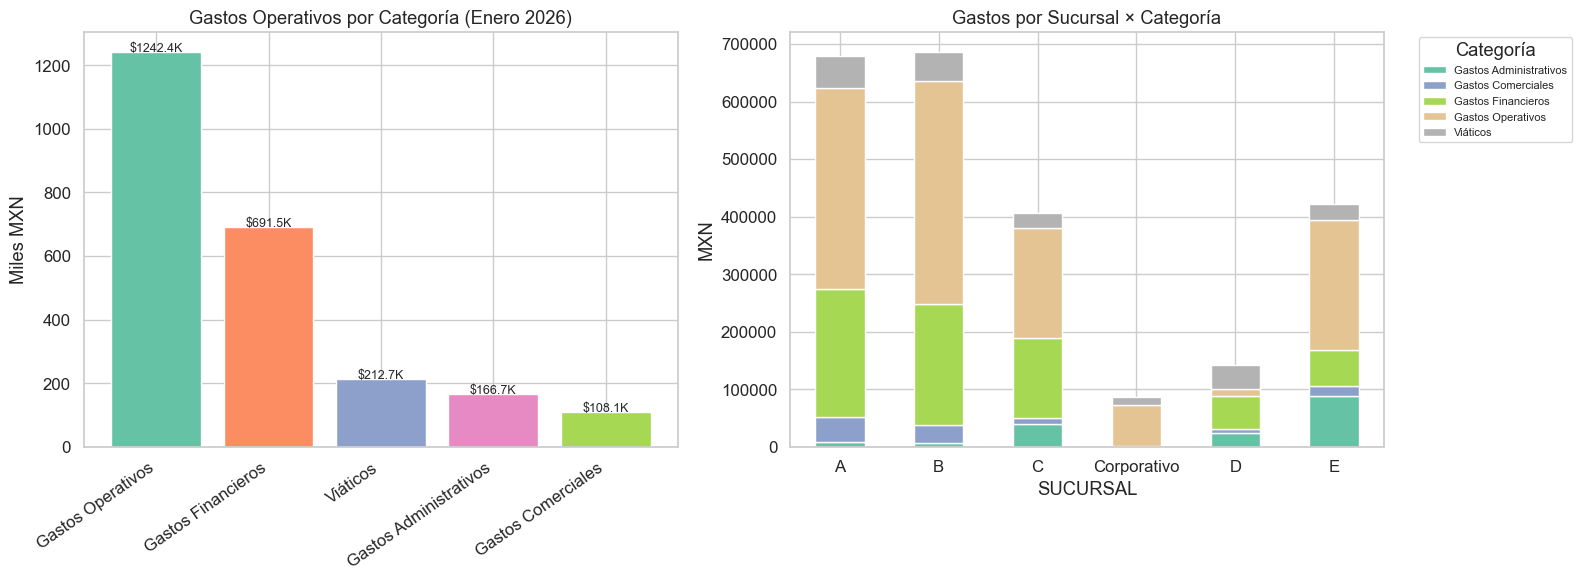


Gasto total enero: $2,421,373.12 MXN


In [ ]:
# --- 4.1 Gastos por categoría ---
gastos_cat = gastos.groupby('CATEGORÍA GASTO')['SUBTOTAL'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
bars = axes[0].bar(range(len(gastos_cat)), gastos_cat.values / 1000, color=sns.color_palette('Set2'))
axes[0].set_xticks(range(len(gastos_cat)))
axes[0].set_xticklabels(gastos_cat.index, rotation=35, ha='right')
axes[0].set_ylabel('Miles MXN')
axes[0].set_title('Gastos Operativos por Categoría (Enero 2026)')
for bar, val in zip(bars, gastos_cat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val/1000:.1f}K', ha='center', fontsize=9)

# Treemap-style: gastos por categoría × sucursal
gastos_suc = gastos.groupby(['SUCURSAL', 'CATEGORÍA GASTO'])['SUBTOTAL'].sum().reset_index()
gastos_pivot = gastos_suc.pivot_table(values='SUBTOTAL', index='SUCURSAL',
                                       columns='CATEGORÍA GASTO', aggfunc='sum', fill_value=0)
gastos_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Gastos por Sucursal × Categoría')
axes[1].set_ylabel('MXN')
axes[1].legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nGasto total enero: ${gastos['SUBTOTAL'].sum():,.2f} MXN")

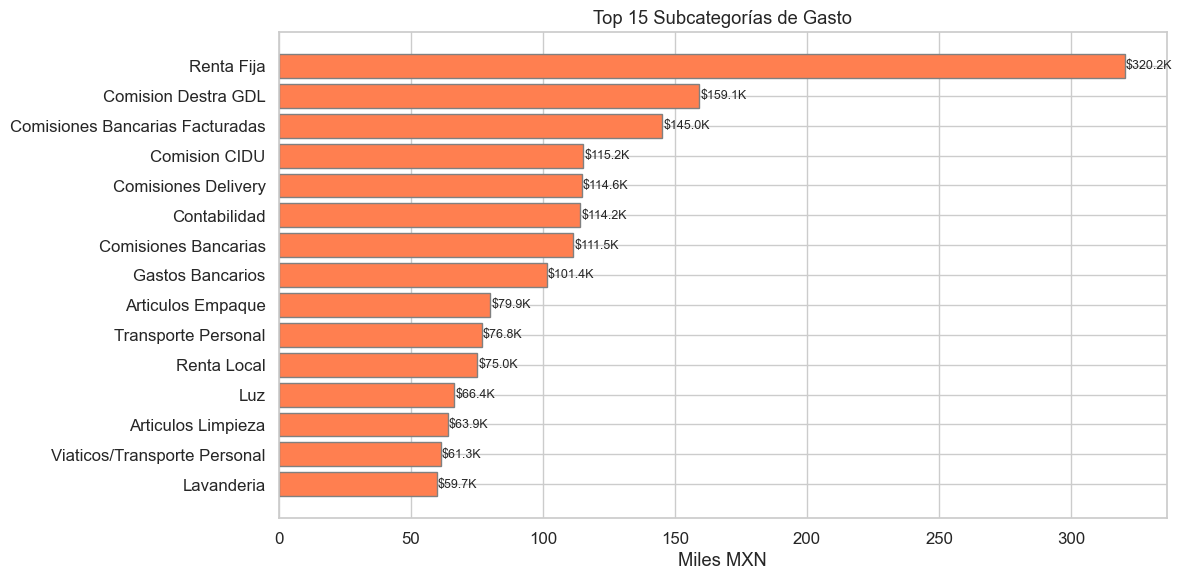

In [ ]:
# --- 4.2 Top subcategorías de gasto ---
gastos_sub = gastos.groupby('SUBCATEGORÍA')['SUBTOTAL'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
gastos_sub_sorted = gastos_sub.sort_values()
ax.barh(gastos_sub_sorted.index, gastos_sub_sorted.values / 1000, color='coral', edgecolor='gray')
ax.set_xlabel('Miles MXN')
ax.set_title('Top 15 Subcategorías de Gasto')
for i, val in enumerate(gastos_sub_sorted.values):
    ax.text(val/1000 + 0.5, i, f'${val/1000:.1f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Análisis de nómina

**Justificación:** El costo laboral suele ser el gasto más significativo en restaurantes. Analizar su composición por sucursal y concepto permite identificar diferencias en la estructura operativa.

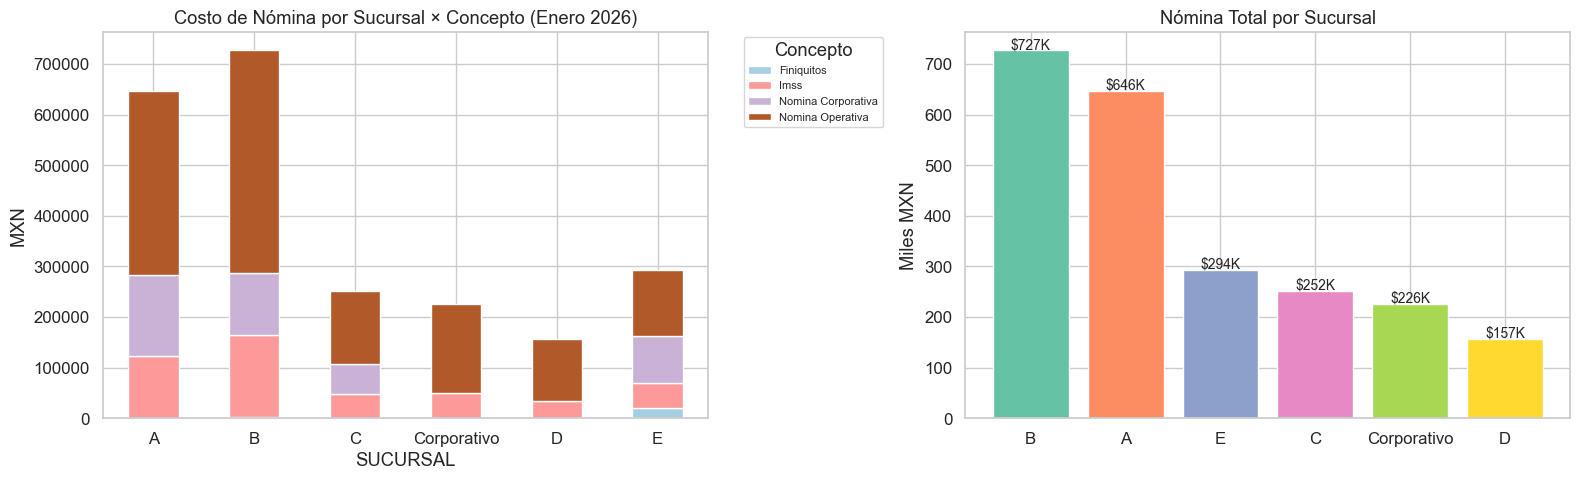

Nómina total enero: $2,301,832.96 MXN

Desglose por concepto:
CONCEPTO_NÓMINA
Nomina Operativa     $1,377,390.83
Imss                   $467,001.16
Nomina Corporativa     $434,466.64
Finiquitos              $22,974.34


In [ ]:
# --- 5.1 Nómina por sucursal y concepto ---
nom_pivot = nomina.pivot_table(values='SUBTOTAL', index='SUCURSAL', columns='CONCEPTO_NÓMINA',
                                aggfunc='sum', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar
nom_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Paired')
axes[0].set_title('Costo de Nómina por Sucursal × Concepto (Enero 2026)')
axes[0].set_ylabel('MXN')
axes[0].legend(title='Concepto', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Total por sucursal
nom_total = nomina.groupby('SUCURSAL')['SUBTOTAL'].sum().sort_values(ascending=False)
bars = axes[1].bar(nom_total.index, nom_total.values / 1000, color=sns.color_palette('Set2'))
axes[1].set_title('Nómina Total por Sucursal')
axes[1].set_ylabel('Miles MXN')
for bar, val in zip(bars, nom_total.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'${val/1000:.0f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Nómina total enero: ${nomina['SUBTOTAL'].sum():,.2f} MXN")
print(f"\nDesglose por concepto:")
print(nomina.groupby('CONCEPTO_NÓMINA')['SUBTOTAL'].sum().sort_values(ascending=False).to_string(float_format='${:,.2f}'.format))

---
## 6. Estado de resultados simplificado por sucursal

**Justificación:** Integrar ingresos, costos de venta, gastos operativos y nómina en una sola vista permite evaluar la rentabilidad real de cada sucursal y del negocio en conjunto.

In [ ]:
# --- 6.1 Construir ER simplificado ---
# Ingresos por sucursal
ingresos = bd.groupby('SUCURSAL')['SUBTOTAL'].sum()
costos_venta = bd.groupby('SUCURSAL')['COSTO TOTAL SIN IVA'].sum()
utilidad_bruta = bd.groupby('SUCURSAL')['UTILIDAD BRUTA'].sum()

# Gastos por sucursal (excluir Corporativo para comparar solo sucursales)
gastos_suc_total = gastos[gastos['SUCURSAL'].isin(['A','B','C','D','E'])].groupby('SUCURSAL')['SUBTOTAL'].sum()

# Nómina por sucursal
nomina_suc_total = nomina.groupby('SUCURSAL')['SUBTOTAL'].sum()

# Construir DataFrame
er = pd.DataFrame({
    'Ingresos': ingresos,
    'Costo de Ventas': costos_venta,
    'Utilidad Bruta': utilidad_bruta,
    'Gastos Operativos': gastos_suc_total,
    'Nómina': nomina_suc_total,
}).fillna(0)

er['EBITDA Aprox'] = er['Utilidad Bruta'] - er['Gastos Operativos'] - er['Nómina']
er['Margen Bruto %'] = er['Utilidad Bruta'] / er['Ingresos']
er['Margen EBITDA %'] = er['EBITDA Aprox'] / er['Ingresos']

# Agregar total
er.loc['TOTAL'] = er.sum()
er.loc['TOTAL', 'Margen Bruto %'] = er.loc['TOTAL', 'Utilidad Bruta'] / er.loc['TOTAL', 'Ingresos']
er.loc['TOTAL', 'Margen EBITDA %'] = er.loc['TOTAL', 'EBITDA Aprox'] / er.loc['TOTAL', 'Ingresos']

print("Estado de Resultados Simplificado — Enero 2026 (MXN)")
print("=" * 100)
display_cols = ['Ingresos', 'Costo de Ventas', 'Utilidad Bruta', 'Gastos Operativos',
                'Nómina', 'EBITDA Aprox', 'Margen Bruto %', 'Margen EBITDA %']
print(er[display_cols].to_string(float_format='${:,.0f}'.format))

Estado de Resultados Simplificado — Enero 2026 (MXN)
              Ingresos  Costo de Ventas  Utilidad Bruta  Gastos Operativos     Nómina  EBITDA Aprox  Margen Bruto %  Margen EBITDA %
SUCURSAL                                                                                                                            
A           $3,164,779         $968,227      $2,196,552           $678,519   $646,360      $871,673              $1               $0
B           $2,392,551         $761,117      $1,631,434           $686,704   $726,891      $217,838              $1               $0
C           $1,139,072         $309,557        $829,515           $405,974   $251,993      $171,548              $1               $0
Corporativo         $0               $0              $0                 $0   $225,866     $-225,866             NaN            $-inf
D             $470,759         $131,096        $339,664           $142,173   $157,106       $40,385              $1               $0
E           $1,8

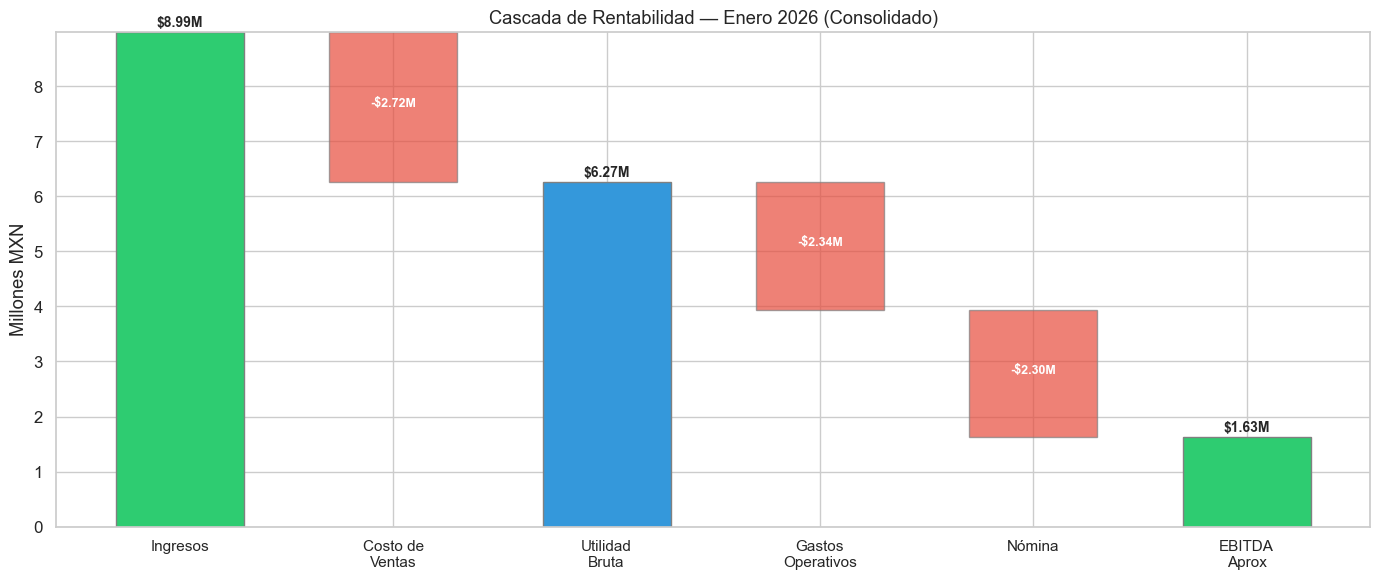

In [ ]:
# --- 6.2 Waterfall de rentabilidad consolidada ---
total = er.loc['TOTAL']
categories = ['Ingresos', 'Costo de\nVentas', 'Utilidad\nBruta', 'Gastos\nOperativos', 'Nómina', 'EBITDA\nAprox']
values = [total['Ingresos'], -total['Costo de Ventas'], total['Utilidad Bruta'],
          -total['Gastos Operativos'], -total['Nómina'], total['EBITDA Aprox']]

fig, ax = plt.subplots(figsize=(14, 6))
colors_wf = ['#2ecc71', '#e74c3c', '#3498db', '#e74c3c', '#e74c3c', '#2ecc71' if values[-1] > 0 else '#e74c3c']

# Simple waterfall
cumulative = 0
for i, (cat, val, col) in enumerate(zip(categories, values, colors_wf)):
    if i in [0, 2, 5]:  # Totals
        ax.bar(i, val/1e6, color=col, edgecolor='gray', width=0.6)
        ax.text(i, val/1e6 + 0.1, f'${val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
    else:  # Decrements
        bottom = cumulative
        ax.bar(i, val/1e6, bottom=bottom/1e6, color=col, edgecolor='gray', width=0.6, alpha=0.7)
        ax.text(i, (bottom + val/2)/1e6, f'-${abs(val)/1e6:.2f}M', ha='center', fontsize=9, color='white', fontweight='bold')
    if i not in [2, 5]:
        cumulative += val

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Millones MXN')
ax.set_title('Cascada de Rentabilidad — Enero 2026 (Consolidado)')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

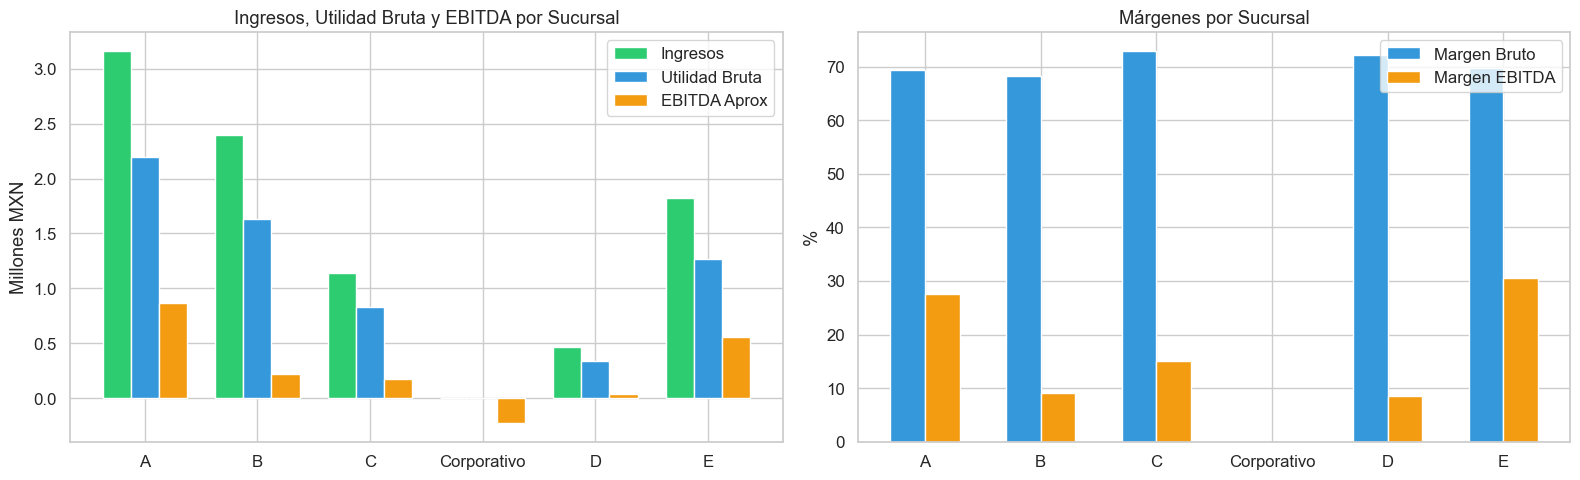

In [ ]:
# --- 6.3 Comparativa de rentabilidad por sucursal ---
er_suc = er.drop('TOTAL')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot agrupado
x = np.arange(len(er_suc))
width = 0.25
axes[0].bar(x - width, er_suc['Ingresos']/1e6, width, label='Ingresos', color='#2ecc71')
axes[0].bar(x, er_suc['Utilidad Bruta']/1e6, width, label='Utilidad Bruta', color='#3498db')
axes[0].bar(x + width, er_suc['EBITDA Aprox']/1e6, width, label='EBITDA Aprox', color='#f39c12')
axes[0].set_xticks(x)
axes[0].set_xticklabels(er_suc.index)
axes[0].set_ylabel('Millones MXN')
axes[0].set_title('Ingresos, Utilidad Bruta y EBITDA por Sucursal')
axes[0].legend()

# Márgenes
axes[1].bar(x - 0.15, er_suc['Margen Bruto %'] * 100, 0.3, label='Margen Bruto', color='#3498db')
axes[1].bar(x + 0.15, er_suc['Margen EBITDA %'] * 100, 0.3, label='Margen EBITDA', color='#f39c12')
axes[1].set_xticks(x)
axes[1].set_xticklabels(er_suc.index)
axes[1].set_ylabel('%')
axes[1].set_title('Márgenes por Sucursal')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## 7. Distribución de precios y volúmenes

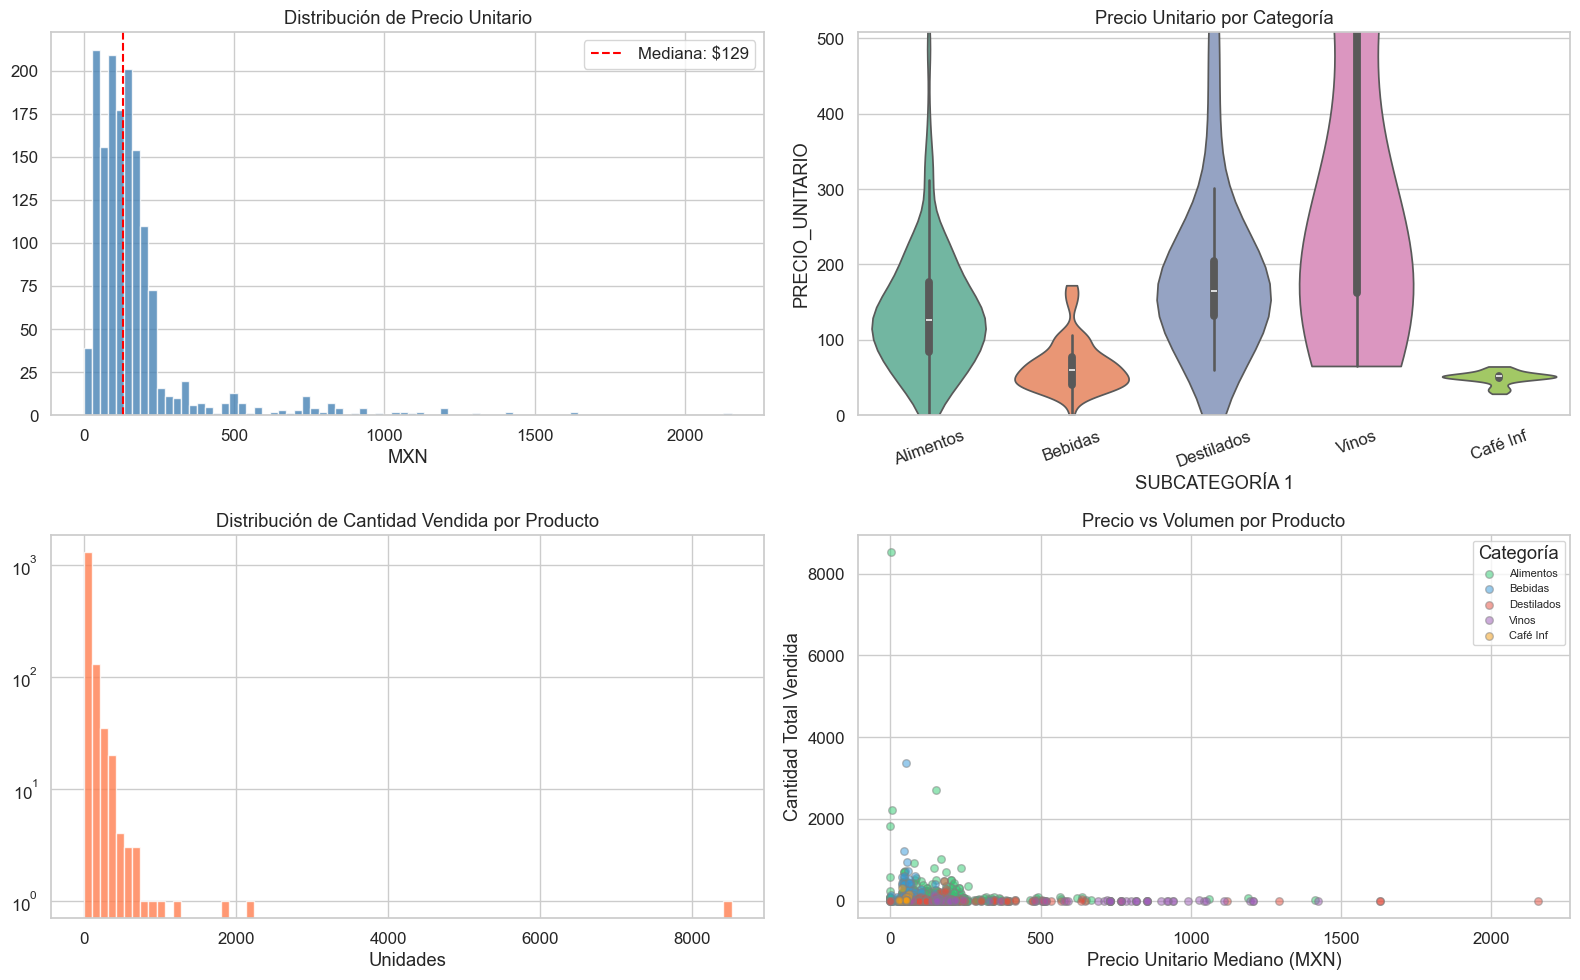

In [ ]:
# --- 7.1 Distribución de precios unitarios y cantidades ---
bd_pos = bd[bd['CANTIDAD'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Precio unitario - histograma
axes[0, 0].hist(bd_pos['PRECIO_UNITARIO'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de Precio Unitario')
axes[0, 0].set_xlabel('MXN')
axes[0, 0].axvline(bd_pos['PRECIO_UNITARIO'].median(), color='red', linestyle='--',
                     label=f"Mediana: ${bd_pos['PRECIO_UNITARIO'].median():.0f}")
axes[0, 0].legend()

# Precio unitario por categoría - violinplot
sns.violinplot(data=bd_pos, x='SUBCATEGORÍA 1', y='PRECIO_UNITARIO', ax=axes[0, 1],
               palette='Set2', cut=0)
axes[0, 1].set_title('Precio Unitario por Categoría')
axes[0, 1].set_ylim(0, bd_pos['PRECIO_UNITARIO'].quantile(0.95))
axes[0, 1].tick_params(axis='x', rotation=20)

# Cantidad vendida - log scale
axes[1, 0].hist(bd_pos['CANTIDAD'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribución de Cantidad Vendida por Producto')
axes[1, 0].set_xlabel('Unidades')
axes[1, 0].set_yscale('log')

# Scatter: Precio vs Cantidad (a nivel producto agregado)
prod = bd_pos.groupby('SUBCATEGORÍA 2').agg(
    Precio_Med=('PRECIO_UNITARIO', 'median'),
    Cantidad_Total=('CANTIDAD', 'sum'),
    Categoria=('SUBCATEGORÍA 1', 'first'),
).reset_index()
for cat, col in cat_colors.items():
    m = prod['Categoria'] == cat
    axes[1, 1].scatter(prod.loc[m, 'Precio_Med'], prod.loc[m, 'Cantidad_Total'],
                        alpha=0.5, color=col, label=cat, edgecolors='gray', s=30)
axes[1, 1].set_xlabel('Precio Unitario Mediano (MXN)')
axes[1, 1].set_ylabel('Cantidad Total Vendida')
axes[1, 1].set_title('Precio vs Volumen por Producto')
axes[1, 1].legend(title='Categoría', fontsize=8)

plt.tight_layout()
plt.show()

---
## 8. Análisis de la categoría de menú (CATEGORÍA MENÚ)

**Justificación:** Esta variable agrupa los productos por su posición en el menú (MAKIS, NIGIRI, BEBIDAS, DESTILADOS, etc.), lo cual es clave para entender la composición de ventas desde la perspectiva operativa del restaurante.

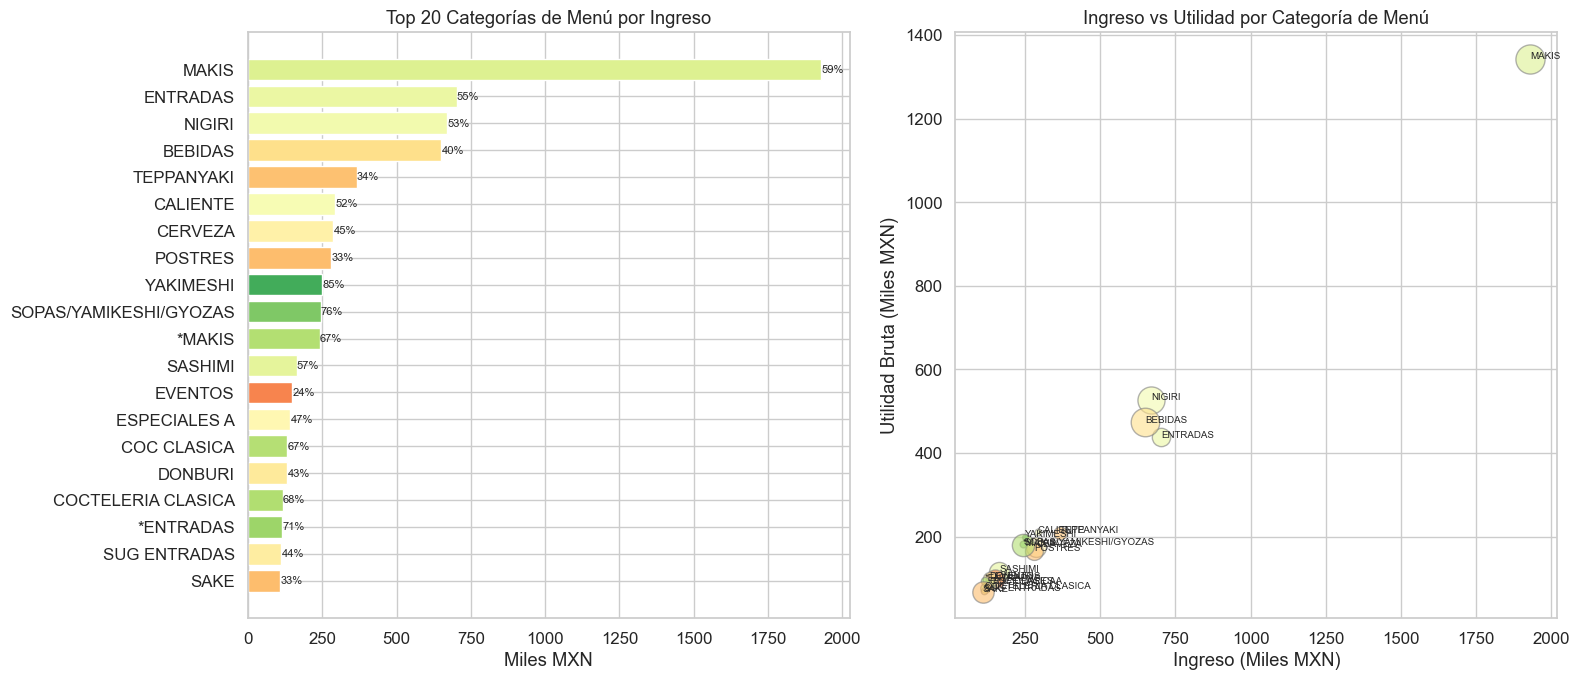

In [ ]:
# --- 8.1 Top categorías de menú por ingreso y margen ---
menu_agg = bd.groupby('CATEGORÍA MENÚ').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso=('SUBTOTAL', 'sum'),
    Margen_Prom=('MARGEN BRUTO', 'mean'),
    Utilidad=('UTILIDAD BRUTA', 'sum'),
).sort_values('Ingreso', ascending=False)

top_menu = menu_agg.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ingreso por categoría de menú
top_sorted = top_menu.sort_values('Ingreso')
bars = axes[0].barh(top_sorted.index, top_sorted['Ingreso'] / 1000,
                     color=[plt.cm.RdYlGn(m) for m in top_sorted['Margen_Prom']])
axes[0].set_xlabel('Miles MXN')
axes[0].set_title('Top 20 Categorías de Menú por Ingreso')
for i, (ing, marg) in enumerate(zip(top_sorted['Ingreso'], top_sorted['Margen_Prom'])):
    axes[0].text(ing/1000 + 1, i, f'{marg:.0%}', va='center', fontsize=8)

# Utilidad vs Ingreso (bubble)
for _, row in top_menu.iterrows():
    axes[1].scatter(row['Ingreso']/1000, row['Utilidad']/1000,
                     s=row['Transacciones']*3, alpha=0.6,
                     color=plt.cm.RdYlGn(row['Margen_Prom']), edgecolors='gray')
    axes[1].annotate(row.name, (row['Ingreso']/1000, row['Utilidad']/1000), fontsize=7)

axes[1].set_xlabel('Ingreso (Miles MXN)')
axes[1].set_ylabel('Utilidad Bruta (Miles MXN)')
axes[1].set_title('Ingreso vs Utilidad por Categoría de Menú')

plt.tight_layout()
plt.show()

---
## 9. Insights clave

### Datos
- **44.7% de registros son placeholders** (SUBTOTAL=0, CANTIDAD=0). Solo 1,482 de 2,678 son ventas reales (~580 productos de 1,764 en catálogo). Filtrarlos corrige el margen promedio de 39% a **~70%**.

### Ingresos
- **Sucursal A lidera** con $3.16M (35% del total) y el ticket más alto (~$6K). **D es la más débil** ($470K, 5.2%).
- **Alimentos = 77%** de ingresos. Bebidas 11%, Destilados 8%. Vinos y Café Inf son marginales (<3%).
- **Producto estrella:** YAKIMESHI MIXTO ($416K, margen 77%).

### Márgenes
- **Mejor margen: Sucursal E. Peor: Sucursal D.**
- **Destilados (~30%) y Vinos (~23%)** tienen márgenes muy por debajo de Alimentos (~44%) y Bebidas (~48%) — oportunidad de repricing.
- **8 productos con utilidad negativa** (-$10.5K total). El mayor: POSTRE CUMPLEAÑOS (-$7.9K, probablemente cortesía).

### Gastos y nómina
- Gastos Operativos dominan (rentas, mantenimiento, servicios básicos).
- Nómina operativa es el mayor costo laboral. **Sucursal A: nómina más alta** ($646K).

### Accionables
1. **Sucursal D**: bajo ingreso, bajo margen, bajo ticket — requiere diagnóstico urgente.
2. **Destilados/Vinos**: renegociar costos o ajustar precios.
3. **Productos con margen negativo**: validar si son cortesías intencionales o errores de costeo.
4. **MAKIS**: categoría de mayor ingreso con buen margen — proteger y potenciar.
5. **Datos**: excluir ~1,200 placeholders de cualquier modelo analítico.